In [1]:
from openai import OpenAI

In [2]:
import os

from dotenv import load_dotenv

load_dotenv()

True

In [3]:
openai_api_key = os.getenv("OPENAI_API_KEY")

In [4]:
openai_api_key

'sk-your-openai-api-key'

In [5]:
openai_client = OpenAI(api_key=openai_api_key, base_url= os.getenv("OPENAI_BASE_URL"))

In [6]:
openai_client

In [14]:
#test model working or not simple test
response = openai_client.chat.completions.create(
    model=os.getenv("OPENAI_BASE_MODEL"),
    messages=[
        {"role": "user", "content": "Hello, world!"}
    ]
)

In [15]:
from IPython.display import display, Markdown

In [16]:
Markdown(response.choices[0].message.content)

Hello, how can I assist you today?

In [17]:
### Let's Read Simple Image

In [18]:
def print_markdown(content):
    display(Markdown(content))

In [19]:
print_markdown("This is a **bold** statement and this is *italic* text.")

This is a **bold** statement and this is *italic* text.

In [20]:
from PIL import Image

In [23]:
image_filename = "test_image.jpg"

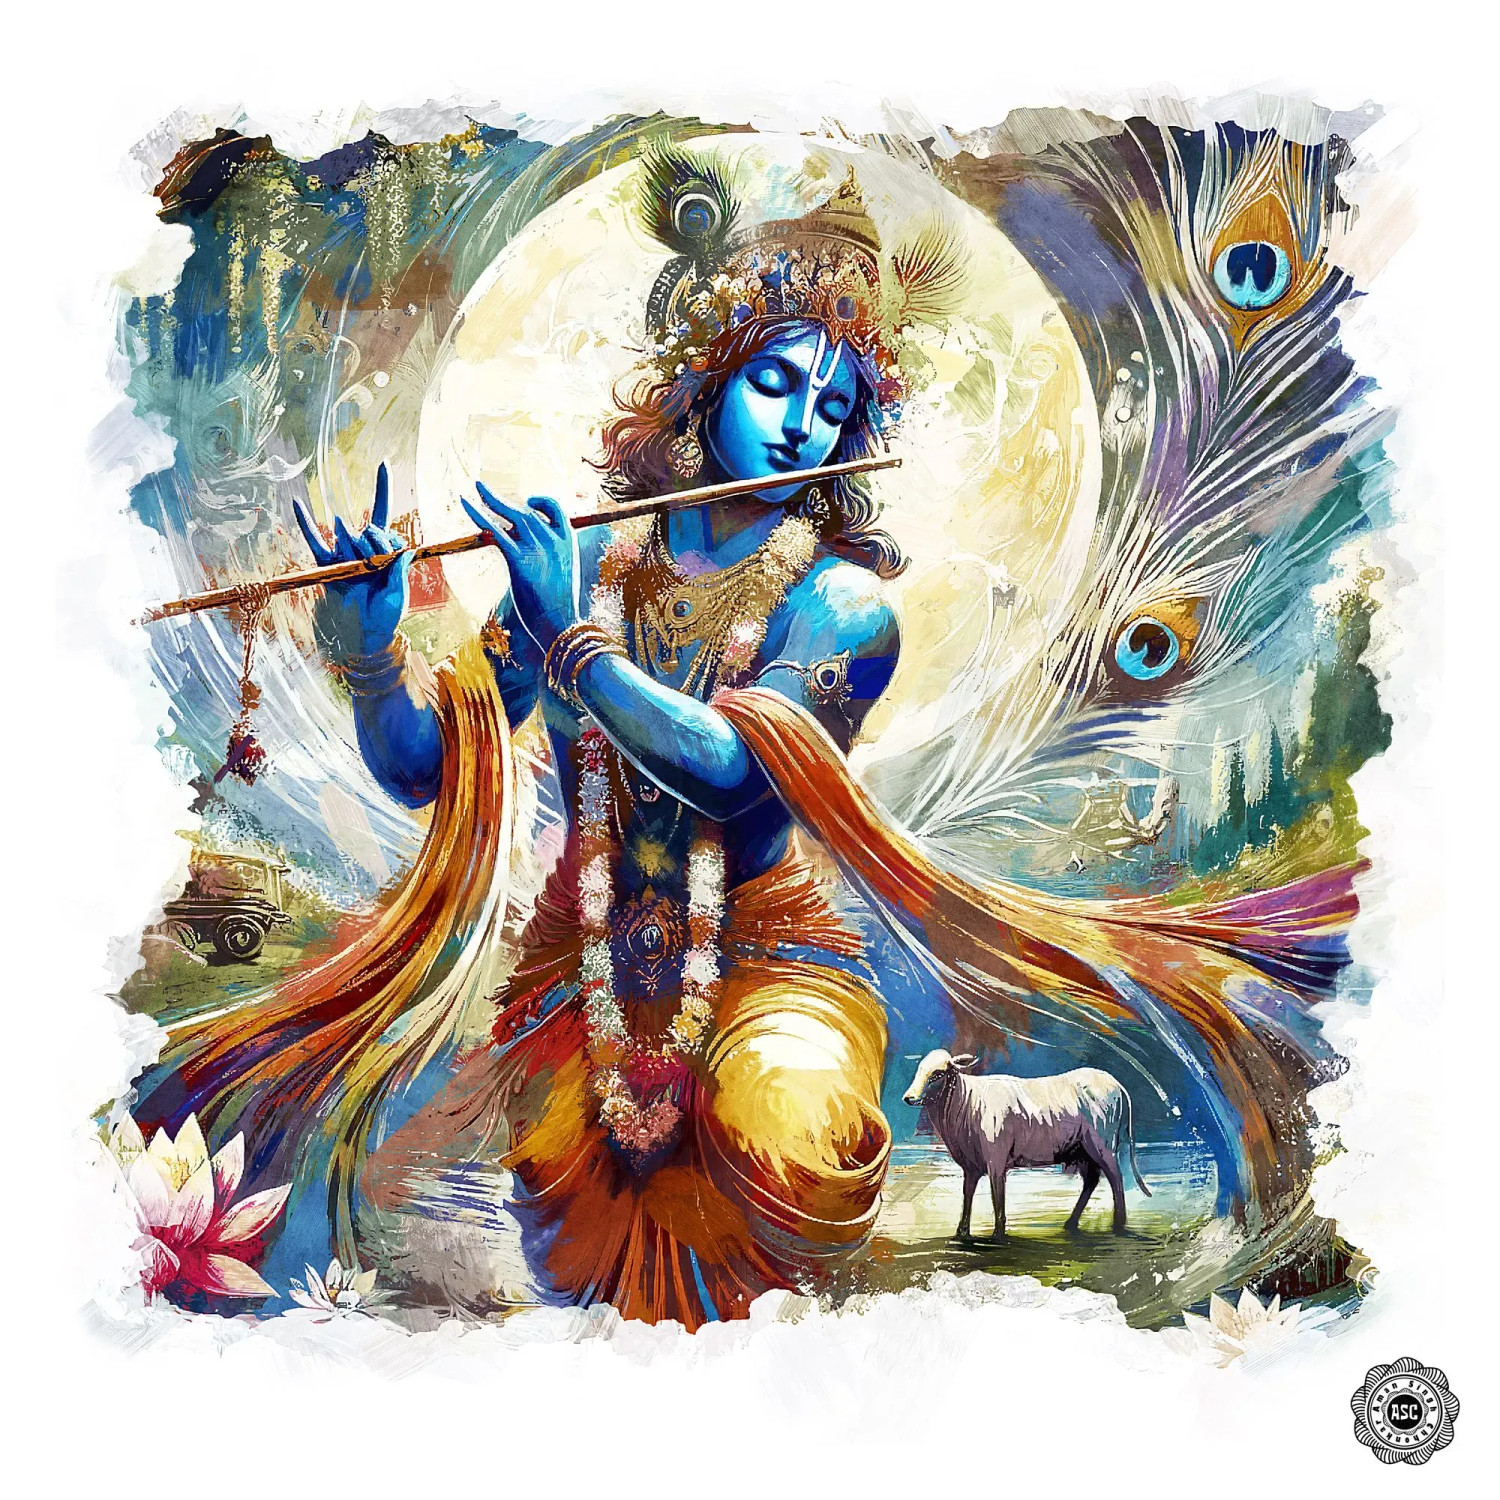

In [25]:
Img = Image.open(image_filename)
display(Img)

In [26]:
print(Img.format)

JPEG


In [27]:
print(Img.size)

(1500, 1500)


In [28]:
print(Img.mode)

RGB


In [29]:
image_to_analyze = "fruit_image.jpg"

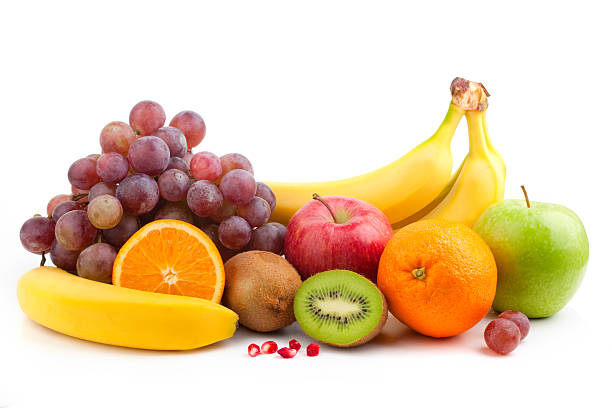

In [30]:
display(Image.open(image_to_analyze))

In [31]:
import io

import base64

In [32]:
def encode_image_to_base64(image_path):
    with open(image_path, "rb") as image_file:
        encoded_string = base64.b64encode(image_file.read()).decode('utf-8')
    return encoded_string

In [33]:
def query_openai_vision(image_path, question):
    encoded_image = encode_image_to_base64(image_path)
    
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": question},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{encoded_image}"
                    }
                }
            ]
        }
    ]
    
    response = openai_client.chat.completions.create(
        model=os.getenv("OPENAI_BASE_MODEL"),
        messages=messages
    )
    
    return response.choices[0].message.content

In [35]:
query_openai_vision(image_to_analyze,"What You see in this image?")

'The image shows a variety of fruits including grapes, bananas, apples, oranges, kiwi, and pomegranate seeds. The fruits are laid out on a white background.'

In [38]:
food_recognition_prompt = """

Context:  I'm analyzing a food image for a calorie tracking application.
Instruction: Please Identify the food item in this image.
Input: [The Image i'm about to share]
Output: Provide the name of the food, a brief description what you see, and if possible mention its typical ingredients or nutrition Profile with what calaries each have.
"""

In [39]:
response = query_openai_vision(
    image_to_analyze,
    food_recognition_prompt
)

In [44]:
Markdown(response)

The image shows a variety of fruits, including:

1. **Grapes** – These are a cluster of purple and green grapes.
2. **bananas** – There are two bananas, one yellow and one green.
3. **oranges** – there is one orange, cut in half.
4. **kiwi** – there is one kiwi fruit.
5. **apple** – there is one red apple.
6. **grapes** – there are some red grapes scattered on the bottom right.

Each of these fruits has different nutritional profiles:
- **Grapes**: Contains carbohydrates, fiber, and antioxidants.
- **bananas**: rich in potassium, vitamin B6, and fiber.
- **orange** (onion): high in vitamin C, fiber, and potassium.
- **kiwi**: high in vitamin C, fiber, and antioxidants.
- **apple**: rich in vitamin C, dietary fiber, and antioxidants.
- **grapes**: contain antioxidants and polyphenols.

These fruits provide a good source of vitamins, minerals, and nutrients, which are beneficial for overall health.

In [50]:
structured_nutrition_prompt = """
# Neutritional Analysis Prompt

## Context:
You are a nutrition expert helping users understand the nutritional content of various foods. You will analyze food images and provide detailed nutritional information.

## Instruction:
Analyze the food item in the provided image and generate a structured nutritional report including macronutrients (carbohydrates, proteins, fats), micronutrients (vitamins, minerals), and estimated calorie content.

## Input:
[The Image i'm about to share]

## Output:

Provide a structured nutritional report in the following format:
- Food Name: <Name of the food item>
- serving_description: <Description of the serving size> (string, "1 slice, '100g","1 cup" examples)
- calories: <Estimated calorie content> (float, in kcal)
- fat_grams (float)
-protein_grams (float)
confidence_level: <Your confidence level in the analysis> (string, "high", "medium", "low")

**IMPORTANT**: Ensure the output is in valid JSON format containing this fields for easy parsing.

EXAMPLE VALID JSON RESPONSE:
{
  "Food Name": "Margherita Pizza",
  "serving_description": "1 slice (100g)",
  "calories": 250.0,
  "fat_grams": 8.0,
  "protein_grams": 10.0,
  "confidence_level": "high"
}

"""

In [51]:
response = query_openai_vision(
    image_to_analyze,
    structured_nutrition_prompt
)

In [54]:
print_markdown(response)

{
  "food_name": "Fingers (banana, kiwi, orange)",
  "serving_description": "1 slice, '100g'",
  "calories": 140.0,
  "fat_grams": 0.8,
  "protein_grams": 0.8,
  "confidence_level": "high"
}